# Results Analysis

Load the latest evaluation record for each model from `results/`.

In [6]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from utils import TFLiteEvalRecord

repo_root = Path.cwd().parent
results_dir = repo_root / "results"

records = []
for p in sorted(results_dir.glob("*.jsonl")):
    with p.open("r", encoding="utf-8") as f:
        lines = f.readlines()
    if not lines:
        continue
    last = json.loads(lines[-1])
    records.append(TFLiteEvalRecord.model_validate(last))

records = sorted(records, key=lambda r: r.model_name)
print(f"Loaded {len(records)} runs from {results_dir}")


Loaded 6 runs from /home/nathan/Documents/tiny-chirp-microflow/results


ROC curves (computed on train set).

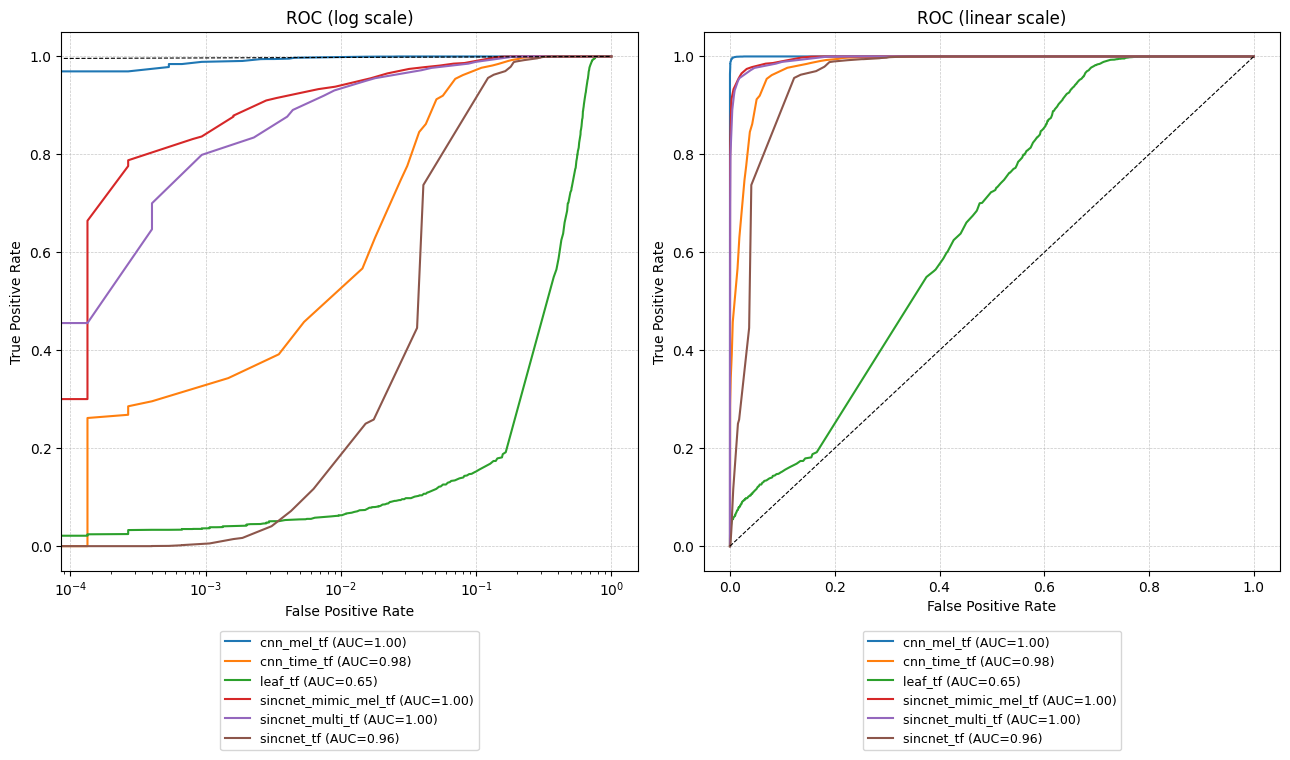

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 8))

for rec in records:
    if rec.train.roc_fpr is None or rec.train.roc_tpr is None or rec.train.auc is None:
        continue
    label = f"{rec.model_name} (AUC={rec.train.auc:.2f})"
    for ax in axes:
        ax.plot(rec.train.roc_fpr, rec.train.roc_tpr, label=label)

for ax, xscale, title in zip(axes, ["log", "linear"], ["ROC (log scale)", "ROC (linear scale)"]):
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
    ax.set_xscale(xscale)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), fontsize=9)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(bottom=0.28)
plt.show()


# Table IV — threshold and prediction metrics on **training set**.

In [8]:
rows = []
for rec in records:
    m = rec.train
    rows.append(
        {
            "Model": rec.model_name,
            "Threshold (t)": m.threshold,
            "Acc.": m.accuracy,
            "Precision": m.precision,
            "Recall": m.recall,
            "F2": m.f2,
        }
    )

df_train = pd.DataFrame(rows).sort_values("F2",ascending=False)

df_train.style.format(
    {
        "Threshold (t)": "{:.3e}",
        "Acc.": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F2": "{:.3f}",
    }
)


,Model,Threshold (t),Acc.,Precision,Recall,F2
0,cnn_mel_tf,5.904e-01,0.996,0.991,0.997,0.996
3,sincnet_mimic_mel_tf,3.803e-01,0.970,0.939,0.975,0.967
4,sincnet_multi_tf,3.320e-01,0.961,0.914,0.977,0.963
1,cnn_time_tf,1.982e-01,0.920,0.819,0.977,0.941
5,sincnet_tf,3.458e-01,0.870,0.726,0.988,0.922
2,leaf_tf,2.754e-05,0.523,0.413,0.989,0.774


# Table V — prediction metrics on **test set**.

In [9]:
rows = []
for rec in records:
    m = rec.test
    rows.append(
        {
            "Model": rec.model_name,
            "Accuracy": m.accuracy,
            "Precision": m.precision,
            "Recall": m.recall,
            "F2": m.f2,
            "Avg Inference (ms)": m.avg_inference_time_ms if m.avg_inference_time_ms is not None else np.nan,
        }
    )

pd.DataFrame(rows).sort_values("Model").style.format(
    {
        "Accuracy": "{:.2f}",
        "Precision": "{:.2f}",
        "Recall": "{:.2f}",
        "F2": "{:.2f}",
        "Avg Inference (ms)": "{:.3f}",
    },
    na_rep="—",
)


,Model,Accuracy,Precision,Recall,F2,Avg Inference (ms)
0,cnn_mel_tf,0.98,0.94,1.00,0.98,0.981
1,cnn_time_tf,0.93,0.83,0.98,0.95,1.797
2,leaf_tf,0.52,0.41,0.98,0.77,13.817
3,sincnet_mimic_mel_tf,0.98,0.95,0.98,0.97,1.811
4,sincnet_multi_tf,0.96,0.90,0.98,0.97,1.204
5,sincnet_tf,0.85,0.69,1.00,0.92,3.838


# Table VI — model characteristics (compute, RAM, flash).

In [ ]:
rows = []
for rec in records:
    rows.append(
        {
            "Model": rec.model_name,
            "Est. MFLOPs": rec.flops_mflops if rec.flops_mflops is not None else np.nan,
            "Arena / RAM (KB)": rec.arena_size_kb if rec.arena_size_kb is not None else np.nan,
            "Flash (KB)": rec.model_size_kb if rec.model_size_kb is not None else np.nan,
            "Preprocessing (ms)": rec.preprocessing_ms if rec.preprocessing_ms is not None else np.nan,
            "Avg Inference (ms)": rec.test.avg_inference_time_ms if rec.test.avg_inference_time_ms is not None else np.nan,
        }
    )

pd.DataFrame(rows).sort_values("Model").style.format(
    {
        "Est. MFLOPs": "{:.3f}",
        "Arena / RAM (KB)": "{:.1f}",
        "Flash (KB)": "{:.1f}",
        "Preprocessing (ms)": "{:.3f}",
        "Avg Inference (ms)": "{:.3f}",
    },
    na_rep="—",
)

# Per-model hyperparameters & timing

Configuration that produced each `results/*.jsonl` row, plus the host-side
preprocessing and inference time. Models without a `hyperparams` block were
trained before the schema bump — re-run their training notebook to populate.

Chip-side timings remain TBD until hardware bring-up.

In [ ]:
from IPython.display import Markdown, display

def _fmt(v, prec=3):
    if v is None:
        return "—"
    if isinstance(v, float):
        return f"{v:.{prec}f}"
    return str(v)

for rec in sorted(records, key=lambda r: r.model_name):
    lines = [f"### {rec.model_name}", ""]

    preproc = rec.preprocessing_ms
    if preproc is None and rec.test.avg_preprocessing_ms is not None:
        preproc = rec.test.avg_preprocessing_ms
    lines.append(
        f"**Timing (host)** — preprocessing: {_fmt(preproc)} ms / clip "
        f"· inference: {_fmt(rec.test.avg_inference_time_ms)} ms / clip "
        f"· **chip total: _TBD_**"
    )
    lines.append("")
    lines.append(
        f"**Resources** — flash: {_fmt(rec.model_size_kb, 2)} KB "
        f"· arena RAM: {_fmt(rec.arena_size_kb, 1)} KB "
        f"· FLOPs: {_fmt(rec.flops_mflops)} M"
    )
    lines.append("")

    if rec.hyperparams:
        lines.append("**Hyperparameters**")
        lines.append("")
        lines.append("| Param | Value |")
        lines.append("| --- | --- |")
        for k, v in rec.hyperparams.items():
            lines.append(f"| `{k}` | {v} |")
    else:
        lines.append("_No hyperparameter record — re-run the training notebook to populate._")
    lines.append("")
    lines.append(f"_source: `results/{rec.model_name}.jsonl` — {rec.timestamp}_")
    lines.append("")
    display(Markdown("\n".join(lines)))